First, load in the necessary packages

In [32]:
# Load in the packages
import numpy as np
# Set up matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
from astropy.io import fits
import astropy.wcs as WCS
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time
# Set up scipy
from scipy.optimize import curve_fit



Filename: /Users/Matylda/Documents/final_data/asteroid/r/PIRATE_165718_OSL_ROE_Asteroids_2_00_Belgica_00_Filter_R_00_2025_10_09_21_34_07.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU    1082   (2048, 2048)   int16 (rescales to uint16)   
[[1399 1399 1399 ... 1399 1399 1399]
 [1399 1399 1399 ... 1399 1399 1399]
 [1399 1399 1399 ... 1399 1399 1399]
 ...
 [1399 1399 1399 ... 1399 1399 1399]
 [1399 1399 1399 ... 1399 1399 1399]
 [1399 1399 1399 ... 1399 1399 1399]]


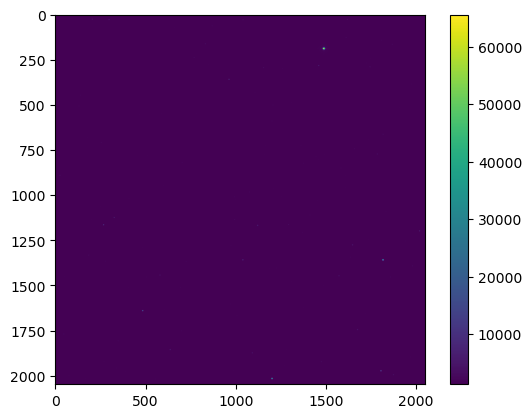

In [33]:
# Load in the image files from three separate nights

image_files = ["/Users/Matylda/Documents/final_data/asteroid/r/PIRATE_165718_OSL_ROE_Asteroids_2_00_Belgica_00_Filter_R_00_2025_10_09_21_34_07.fits",
               "/Users/Matylda/Documents/final_data/asteroid/r/PIRATE_167140_OSL_ROE_Asteroids_2_00_Belgica_00_Filter_R_00_2025_10_19_20_56_12.fits",
               "/Users/Matylda/Documents/final_data/asteroid/r/PIRATE_167827_OSL_ROE_Asteroids_2_00_Belgica_00_Filter_R_00_2025_10_22_19_48_43.fits"]

# Open the FITS file
hdul = fits.open(image_files[0])
hdul.info()

image_data = hdul[0].data

print(image_data)

plt.imshow(image_data)
plt.colorbar()
plt.show()

In [34]:
wcs = WCS.WCS(hdul[0].header)
#print(wcs)

t_obs = hdul[0].header['DATE-OBS']
#print(t_obs)

# Get the pixel in julian days 

times = []

for i in range(len(image_files)):
    hdul = fits.open(image_files[i])
    t_obs = hdul[0].header['DATE-OBS']
    t_obs_jd = Time(t_obs, format='isot', scale='utc').jd
    times.append(t_obs_jd)

print(times)


[2460958.3987005646, 2460968.372367383, 2460971.325504617]


a floating-point value was expected. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


In [35]:
# Get the pixel coordinates of r-filter captures from across the three nights 

xCoords = [994.328, 1049.31, 1038.99]
yCoords = [1011.69, 980.556, 980.556]
pixel_coords = np.array([[xCoord, yCoord]])
world_coords = wcs.wcs_pix2world(pixel_coords, 1)

# Get a list of RA and Dec values for the three nights

ra_list = []
dec_list = []

for i in range(len(image_files)):
    hdul = fits.open(image_files[i])
    wcs = WCS.WCS(hdul[0].header)
    pixel_coords = np.array([[xCoords[i], yCoords[i]]])
    world_coords = wcs.wcs_pix2world(pixel_coords, 1)
    ra = world_coords[0][0]
    dec = world_coords[0][1]
    ra_list.append(ra)
    dec_list.append(dec)

print(f"RA: {ra_list}, Dec: {dec_list}")

RA: [347.3303746536821, 346.5765643177048, 346.5039775030589], Dec: [-14.729670105902304, -14.591278288648487, -14.466643048716383]


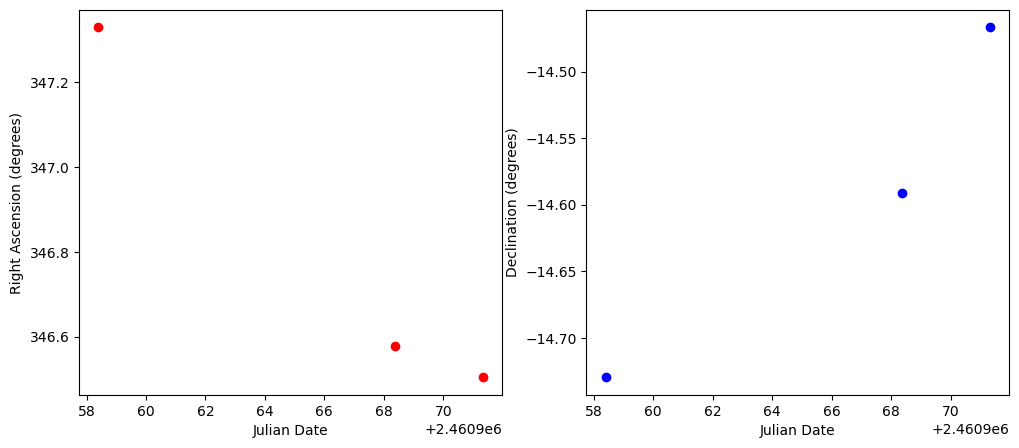

In [42]:
# Now we have the times, RA, and Dec from across three different nights
# We can use these to fit the orbital parameters of the asteroid 

# Plot the observed RA and Dec separately over time
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(times, ra_list, color='red', label='Observed RA')
axes[0].set_ylabel('Right Ascension (degrees)')
axes[0].set_xlabel('Julian Date')

axes[1].scatter(times, dec_list, color='blue', label='Observed Dec')
axes[1].set_ylabel('Declination (degrees)')
axes[1].set_xlabel('Julian Date')



plt.show()

